## 1. Setup and final model verification

This section loads the final four-class EfficientNetV2B0 model and verifies the browser deployment contract before any export is performed.

The fixed class order is `Cat`, `Dog`, `Bird`, and `Unknown`. Images are decoded as RGB, resized to `224 × 224` with aspect-ratio-preserving bilinear padding, and kept in the `[0,255]` pixel range because the saved model performs its own rescaling.

The final Keras model must exist at `Model Building/Models/Final/cat_dog_bird_unknown.keras`. The notebook also identifies the last four-dimensional EfficientNetV2B0 feature tensor and rebuilds the classifier as a feature model and classification head for browser Grad-CAM.

In [1]:
import os

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from pathlib import Path
import hashlib
import json
import random
import shutil
import socket
import subprocess
import sys
import tarfile
import threading
import time
import urllib.request
from functools import partial
from http.server import SimpleHTTPRequestHandler, ThreadingHTTPServer

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
from IPython.display import display


SEED = 42
CLASS_NAMES = ["Cat", "Dog", "Bird", "Unknown"]
IMAGE_SIZE = 224
SAMPLES_PER_CLASS = 15
TFJS_VERSION = "4.22.0"

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
tf.config.experimental.enable_tensor_float_32_execution(False)

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass


def find_project_root(start_path):
    start_path = Path(start_path).resolve()

    for candidate in [start_path, *start_path.parents]:
        if (candidate / "Model Building").is_dir():
            return candidate
        if candidate.name == "Model Building":
            return candidate.parent

    raise FileNotFoundError(
        "Could not find the project root containing Model Building."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
MODEL_BUILDING_DIR = PROJECT_ROOT / "Model Building"
FINAL_MODEL_DIR = MODEL_BUILDING_DIR / "Models" / "Final"
FINAL_KERAS_MODEL_PATH = FINAL_MODEL_DIR / "cat_dog_bird_unknown.keras"
TEST_DIR = MODEL_BUILDING_DIR / "Datasets" / "Final Dataset" / "Test"
BROWSER_TEST_DIR = MODEL_BUILDING_DIR / "Browser Test"
TEMP_DIR = BROWSER_TEST_DIR / "Temp"
TEMP_IMAGES_DIR = TEMP_DIR / "images"
TEMP_SAVED_MODEL_DIR = TEMP_DIR / "saved_model"
TEMP_TFJS_MODELS_DIR = TEMP_DIR / "models"
TEMP_VENDOR_DIR = TEMP_DIR / "vendor"
RESULTS_PATH = BROWSER_TEST_DIR / "results.csv"
COMPARISON_PATH = BROWSER_TEST_DIR / "gradcam_comparison.png"
FINAL_TFJS_DIR = FINAL_MODEL_DIR / "TensorFlowJS"
WEB_APP_MODEL_DIR = PROJECT_ROOT / "Web App" / "model"
WEB_APP_WASM_DIR = PROJECT_ROOT / "Web App" / "wasm"
REFERENCE_PATH = TEMP_DIR / "keras_reference.json"
RAW_BROWSER_RESULTS_PATH = TEMP_DIR / "browser_results.json"
WINNER_PATH = TEMP_DIR / "winner.json"

for folder in [
    FINAL_MODEL_DIR,
    BROWSER_TEST_DIR,
    TEMP_DIR,
    TEMP_IMAGES_DIR,
    TEMP_SAVED_MODEL_DIR,
    TEMP_TFJS_MODELS_DIR,
    TEMP_VENDOR_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

if not FINAL_KERAS_MODEL_PATH.is_file():
    raise FileNotFoundError(
        "Final Keras model not found at "
        "Model Building/Models/Final/cat_dog_bird_unknown.keras"
    )

model = tf.keras.models.load_model(
    FINAL_KERAS_MODEL_PATH,
    compile=False,
)

backbone_candidates = [
    layer
    for layer in model.layers
    if isinstance(layer, tf.keras.Model)
    and "efficientnet" in layer.name.lower()
]

if len(backbone_candidates) != 1:
    raise ValueError(
        "Expected one nested EfficientNet backbone, "
        f"but found {len(backbone_candidates)}."
    )

backbone = backbone_candidates[0]
backbone_index = model.layers.index(backbone)

last_conv_layer = next(
    layer
    for layer in reversed(backbone.layers)
    if hasattr(layer, "output")
    and len(layer.output.shape) == 4
)

backbone_feature_extractor = tf.keras.Model(
    backbone.input,
    last_conv_layer.output,
    name="efficientnet_feature_extractor",
)

x = model.input
for layer in model.layers[1:backbone_index]:
    try:
        x = layer(x, training=False)
    except TypeError:
        x = layer(x)

feature_output = backbone_feature_extractor(x, training=False)
feature_model = tf.keras.Model(
    model.input,
    feature_output,
    name="gradcam_feature",
)

head_input = tf.keras.Input(
    shape=tuple(feature_output.shape[1:]),
    name="feature_input",
)
y = head_input

for layer in model.layers[backbone_index + 1:]:
    try:
        y = layer(y, training=False)
    except TypeError:
        y = layer(y)

head_model = tf.keras.Model(
    head_input,
    y,
    name="gradcam_head",
)

verification_input = tf.zeros(
    (1, IMAGE_SIZE, IMAGE_SIZE, 3),
    dtype=tf.float32,
)
full_probabilities = model(verification_input, training=False).numpy()
split_probabilities = head_model(
    feature_model(verification_input, training=False),
    training=False,
).numpy()

split_difference = float(
    np.max(np.abs(full_probabilities - split_probabilities))
)

if tuple(model.input_shape[1:]) != (IMAGE_SIZE, IMAGE_SIZE, 3):
    raise ValueError(f"Unexpected model input shape: {model.input_shape}")

if int(model.output_shape[-1]) != len(CLASS_NAMES):
    raise ValueError(f"Unexpected model output shape: {model.output_shape}")

if split_difference > 1e-5:
    raise ValueError(
        "The rebuilt feature and head models do not match the full model. "
        f"Maximum difference: {split_difference:.8f}"
    )

print("TensorFlow version:", tf.__version__)
print("GPU available:", "Yes" if tf.config.list_physical_devices("GPU") else "No")
print("Final model: Model Building/Models/Final/cat_dog_bird_unknown.keras")
print("Class order:", ", ".join(CLASS_NAMES))
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)
print("Backbone:", backbone.name)
print("Grad-CAM layer:", last_conv_layer.name)
print("Feature shape:", tuple(feature_model.output_shape))
print("Split-model maximum difference:", f"{split_difference:.8f}")

TensorFlow version: 2.21.0
GPU available: Yes
Final model: Model Building/Models/Final/cat_dog_bird_unknown.keras
Class order: Cat, Dog, Bird, Unknown
Input shape: (None, 224, 224, 3)
Output shape: (None, 4)
Backbone: efficientnetv2-b0
Grad-CAM layer: top_activation
Feature shape: (None, 7, 7, 1280)
Split-model maximum difference: 0.00000000


## 2. Benchmark sample and Keras references

The browser benchmark uses 60 fixed images from the final Open Images Test split: 15 Cat, 15 Dog, 15 Bird, and 15 Unknown images selected with seed `42`.

The same images are used for every browser configuration. One reproducible random image from the 60-image sample is reserved for the final visual comparison showing the original image, Keras Grad-CAM, and the winning browser Grad-CAM.

Keras predictions, all four probabilities, prediction time, Grad-CAM time, and normalized Grad-CAM arrays are generated as the reference outputs. Temporary images and reference data remain under `Model Building/Browser Test/Temp` until the final export has been verified.

In [2]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}


def project_relative(path):
    return Path(path).resolve().relative_to(PROJECT_ROOT).as_posix()


def load_image_tensor(image_path):
    image_bytes = tf.io.read_file(str(image_path))
    image = tf.image.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.cast(image, tf.float32)
    image = tf.image.resize_with_pad(
        image,
        IMAGE_SIZE,
        IMAGE_SIZE,
        method="bilinear",
        antialias=False,
    )
    return tf.expand_dims(image, axis=0)


def make_keras_gradcam(image_tensor, class_index):
    start_time = time.perf_counter()

    with tf.GradientTape() as tape:
        features = feature_model(image_tensor, training=False)
        tape.watch(features)
        probabilities = head_model(features, training=False)
        class_score = probabilities[:, class_index]

    gradients = tape.gradient(class_score, features)
    weights = tf.reduce_mean(gradients, axis=(1, 2))
    heatmap = tf.reduce_sum(
        features * weights[:, None, None, :],
        axis=-1,
    )
    heatmap = tf.nn.relu(heatmap)[0]
    heatmap_max = tf.reduce_max(heatmap)
    heatmap = tf.where(
        heatmap_max > 0,
        heatmap / heatmap_max,
        tf.zeros_like(heatmap),
    )

    heatmap_array = heatmap.numpy().astype(np.float32)
    elapsed_ms = (time.perf_counter() - start_time) * 1000
    return heatmap_array, elapsed_ms


if TEMP_IMAGES_DIR.exists():
    shutil.rmtree(TEMP_IMAGES_DIR)
TEMP_IMAGES_DIR.mkdir(parents=True, exist_ok=True)

selection_rng = random.Random(SEED)
selected_samples = []

for class_index, class_name in enumerate(CLASS_NAMES):
    class_dir = TEST_DIR / class_name

    if not class_dir.is_dir():
        raise FileNotFoundError(
            f"Missing Test class folder: Model Building/Datasets/Final Dataset/Test/{class_name}"
        )

    image_paths = sorted(
        path
        for path in class_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

    if len(image_paths) < SAMPLES_PER_CLASS:
        raise ValueError(
            f"{class_name} contains only {len(image_paths)} supported images."
        )

    class_samples = selection_rng.sample(
        image_paths,
        SAMPLES_PER_CLASS,
    )

    for sample_number, source_path in enumerate(class_samples, start=1):
        sample_id = f"{class_name.lower()}_{sample_number:02d}"
        copied_name = f"{sample_id}{source_path.suffix.lower()}"
        copied_path = TEMP_IMAGES_DIR / copied_name
        shutil.copy2(source_path, copied_path)

        selected_samples.append(
            {
                "sample_id": sample_id,
                "true_class": class_name,
                "true_index": class_index,
                "source_path": project_relative(source_path),
                "browser_path": f"images/{copied_name}",
            }
        )

comparison_sample = random.Random(SEED).choice(selected_samples)
comparison_sample_id = comparison_sample["sample_id"]

warmup_tensor = tf.zeros(
    (1, IMAGE_SIZE, IMAGE_SIZE, 3),
    dtype=tf.float32,
)
_ = model(warmup_tensor, training=False).numpy()
_ = head_model(
    feature_model(warmup_tensor, training=False),
    training=False,
).numpy()

reference_records = []

for sample_number, sample in enumerate(selected_samples, start=1):
    image_path = TEMP_DIR / sample["browser_path"]
    image_tensor = load_image_tensor(image_path)

    prediction_start = time.perf_counter()
    probabilities = model(image_tensor, training=False).numpy()[0]
    prediction_ms = (time.perf_counter() - prediction_start) * 1000

    predicted_index = int(np.argmax(probabilities))
    heatmap, gradcam_ms = make_keras_gradcam(
        image_tensor,
        predicted_index,
    )

    record = {
        **sample,
        "predicted_index": predicted_index,
        "predicted_class": CLASS_NAMES[predicted_index],
        "probabilities": [float(value) for value in probabilities],
        "winning_confidence": float(probabilities[predicted_index]),
        "prediction_ms": float(prediction_ms),
        "gradcam_ms": float(gradcam_ms),
        "heatmap_shape": list(heatmap.shape),
        "heatmap": [float(value) for value in heatmap.reshape(-1)],
    }
    reference_records.append(record)

    if sample_number % 10 == 0 or sample_number == len(selected_samples):
        print(f"Keras references: {sample_number}/{len(selected_samples)}")

reference_payload = {
    "seed": SEED,
    "class_names": CLASS_NAMES,
    "image_size": IMAGE_SIZE,
    "comparison_sample_id": comparison_sample_id,
    "samples": reference_records,
}

REFERENCE_PATH.write_text(
    json.dumps(reference_payload, indent=2),
    encoding="utf-8",
)

counts = pd.Series(
    [record["true_class"] for record in reference_records]
).value_counts().reindex(CLASS_NAMES)

display(counts.rename("Benchmark images").to_frame())
print("Total benchmark images:", len(reference_records))
print("Comparison sample:", comparison_sample_id)
print("Keras reference data saved under Model Building/Browser Test/Temp.")

Keras references: 10/60
Keras references: 20/60
Keras references: 30/60
Keras references: 40/60
Keras references: 50/60
Keras references: 60/60


,Benchmark images
Cat,15
Dog,15
Bird,15
Unknown,15


Total benchmark images: 60
Comparison sample: bird_11
Keras reference data saved under Model Building/Browser Test/Temp.


## 3. Browser configurations and headless benchmark runner

The final browser model is exported as a TensorFlow.js GraphModel rather than a LayersModel. The exported graph accepts the same 224 × 224 RGB input used by Keras and returns both the four class probabilities and the `top_activation` feature map required for Grad-CAM.

Training-only augmentation layers are bypassed because they are inactive during inference. EfficientNetV2B0's internal rescaling and normalization remain inside the exported computation graph as TensorFlow operations, so the browser still receives pixel values in `[0,255]`.

The browser computes the exact softmax-score Grad-CAM channel weights from the trained Dense classification kernel. Fifteen configurations compare JavaScript or TensorFlow.js resizing, CPU, WebGL, WASM or WebGPU execution, and several Grad-CAM gradient-weight transformations.

In [3]:
import re

BROWSER_CONFIGURATIONS = [
    {
        "configuration": "JavaScript resize + CPU + standard Grad-CAM",
        "resize_method": "JavaScript resize",
        "backend": "cpu",
        "gradcam_method": "standard_mean",
    },
    {
        "configuration": "JavaScript resize + WebGL + standard Grad-CAM",
        "resize_method": "JavaScript resize",
        "backend": "webgl",
        "gradcam_method": "standard_mean",
    },
    {
        "configuration": "JavaScript resize + WASM + standard Grad-CAM",
        "resize_method": "JavaScript resize",
        "backend": "wasm",
        "gradcam_method": "standard_mean",
    },
    {
        "configuration": "JavaScript resize + WebGPU + standard Grad-CAM",
        "resize_method": "JavaScript resize",
        "backend": "webgpu",
        "gradcam_method": "standard_mean",
    },
    {
        "configuration": "Graph resize + CPU + standard Grad-CAM",
        "resize_method": "Graph resize",
        "backend": "cpu",
        "gradcam_method": "standard_mean",
    },
    {
        "configuration": "Graph resize + WebGL + standard Grad-CAM",
        "resize_method": "Graph resize",
        "backend": "webgl",
        "gradcam_method": "standard_mean",
    },
    {
        "configuration": "Graph resize + WASM + standard Grad-CAM",
        "resize_method": "Graph resize",
        "backend": "wasm",
        "gradcam_method": "standard_mean",
    },
    {
        "configuration": "Graph resize + WebGPU + standard Grad-CAM",
        "resize_method": "Graph resize",
        "backend": "webgpu",
        "gradcam_method": "standard_mean",
    },
    {
        "configuration": "JavaScript resize + WebGPU + positive-gradient Grad-CAM",
        "resize_method": "JavaScript resize",
        "backend": "webgpu",
        "gradcam_method": "positive_mean",
    },
    {
        "configuration": "Graph resize + CPU + positive-gradient Grad-CAM",
        "resize_method": "Graph resize",
        "backend": "cpu",
        "gradcam_method": "positive_mean",
    },
    {
        "configuration": "Graph resize + WebGL + positive-gradient Grad-CAM",
        "resize_method": "Graph resize",
        "backend": "webgl",
        "gradcam_method": "positive_mean",
    },
    {
        "configuration": "Graph resize + WebGPU + positive-gradient Grad-CAM",
        "resize_method": "Graph resize",
        "backend": "webgpu",
        "gradcam_method": "positive_mean",
    },
    {
        "configuration": "Graph resize + WebGPU + absolute-gradient Grad-CAM",
        "resize_method": "Graph resize",
        "backend": "webgpu",
        "gradcam_method": "absolute_mean",
    },
    {
        "configuration": "Graph resize + WebGPU + squared-gradient Grad-CAM",
        "resize_method": "Graph resize",
        "backend": "webgpu",
        "gradcam_method": "squared_mean",
    },
    {
        "configuration": "Graph resize + WebGPU + maximum-gradient Grad-CAM",
        "resize_method": "Graph resize",
        "backend": "webgpu",
        "gradcam_method": "maximum",
    },
]


def find_converter():
    candidates = [
        Path.home() / "tfjs-converter-env" / "bin" / "tensorflowjs_converter",
        Path.home() / "image-classifier-env" / "bin" / "tensorflowjs_converter",
    ]

    command_path = shutil.which("tensorflowjs_converter")
    if command_path:
        candidates.append(Path(command_path))

    for candidate in candidates:
        if candidate.is_file():
            return candidate

    raise FileNotFoundError(
        "tensorflowjs_converter was not found. Expected it in "
        "~/tfjs-converter-env or the active environment."
    )


def run_command(command, cwd=None):
    completed = subprocess.run(
        [str(part) for part in command],
        cwd=str(cwd) if cwd else None,
        text=True,
        capture_output=True,
    )

    if completed.returncode != 0:
        raise RuntimeError(
            "Command failed:\n"
            + " ".join(str(part) for part in command)
            + "\n\nStandard output:\n"
            + completed.stdout
            + "\n\nError output:\n"
            + completed.stderr
        )

    return completed


def convert_saved_model(source_dir, output_dir):
    source_dir = source_dir.resolve()
    output_dir = output_dir.resolve()
    temp_root = TEMP_DIR.resolve()

    if output_dir.exists():
        shutil.rmtree(output_dir)

    output_dir.parent.mkdir(parents=True, exist_ok=True)

    try:
        relative_source = source_dir.relative_to(temp_root)
        relative_output = output_dir.relative_to(temp_root)
    except ValueError as error:
        raise ValueError(
            "TensorFlow.js conversion files must remain inside "
            "Model Building/Browser Test/Temp."
        ) from error

    run_command(
        [
            CONVERTER_PATH,
            "--input_format=tf_saved_model",
            "--output_format=tfjs_graph_model",
            "--signature_name=serving_default",
            "--saved_model_tags=serve",
            relative_source.as_posix(),
            relative_output.as_posix(),
        ],
        cwd=temp_root,
    )

    model_json_path = output_dir / "model.json"
    if not model_json_path.is_file():
        raise FileNotFoundError(
            "TensorFlow.js conversion completed without creating "
            f"{model_json_path.relative_to(PROJECT_ROOT)}"
        )


def download_and_extract_npm_package(package_name, version, output_dir):
    encoded_name = package_name.replace("@", "").replace("/", "-")
    archive_name = encoded_name.split("-", 1)[-1]
    archive_url = (
        f"https://registry.npmjs.org/{package_name}/-/"
        f"{archive_name}-{version}.tgz"
    )
    archive_path = TEMP_DIR / f"{encoded_name}-{version}.tgz"

    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    urllib.request.urlretrieve(archive_url, archive_path)

    with tarfile.open(archive_path, "r:gz") as archive:
        archive.extractall(output_dir)

    archive_path.unlink()


def patch_wasm_fused_conv_bias():
    wasm_backend_path = (
        TEMP_VENDOR_DIR
        / "tfjs-backend-wasm"
        / "package"
        / "dist"
        / "tf-backend-wasm.js"
    )

    if not wasm_backend_path.is_file():
        raise FileNotFoundError(
            "TensorFlow.js WASM backend JavaScript was not found."
        )

    source = wasm_backend_path.read_text(encoding="utf-8")
    patch_marker = "Notebook 5 WASM rank-4 bias compatibility patch"

    if patch_marker in source:
        return "already present"

    error_text = "FusedConv2D only supports rank-1 bias but got"
    error_position = source.find(error_text)

    if error_position < 0:
        raise RuntimeError(
            "The expected TensorFlow.js WASM FusedConv2D bias check "
            "was not found. The installed backend may have changed."
        )

    first_match = None
    for match in re.finditer(
        r"if\s*\(\s*biasData\.shape\.length\s*!==\s*1\s*\)\s*\{",
        source[:error_position],
    ):
        first_match = match

    if first_match is None:
        raise RuntimeError(
            "Could not locate the WASM rank-1 FusedConv2D bias check."
        )

    def find_block_end(text, block_start):
        opening_brace = text.find("{", block_start)
        if opening_brace < 0:
            raise RuntimeError("Could not find the start of a JavaScript block.")

        depth = 0
        quote = None
        escaped = False

        for index in range(opening_brace, len(text)):
            character = text[index]

            if quote is not None:
                if escaped:
                    escaped = False
                elif character == "\\":
                    escaped = True
                elif character == quote:
                    quote = None
                continue

            if character in {"'", '"', "`"}:
                quote = character
            elif character == "{":
                depth += 1
            elif character == "}":
                depth -= 1
                if depth == 0:
                    return index + 1

        raise RuntimeError("Could not find the end of a JavaScript block.")

    first_end = find_block_end(source, first_match.start())

    second_match = re.search(
        r"if\s*\(\s*biasData\.shape\[0\]\s*!==\s*"
        r"outputChannels\s*\)\s*\{",
        source[first_end:],
    )

    if second_match is None:
        raise RuntimeError(
            "Could not locate the WASM FusedConv2D output-channel bias check."
        )

    second_start = first_end + second_match.start()
    second_end = find_block_end(source, second_start)

    replacement = '''
        /* Notebook 5 WASM rank-4 bias compatibility patch */
        var biasShape = biasData.shape;
        var biasElementCount = biasShape.reduce(
            function (total, dimension) {
                return total * dimension;
            },
            1
        );
        var rankOneBias = biasShape.length === 1;
        var broadcastableRankFourBias =
            biasShape.length === 4 &&
            biasShape[0] === 1 &&
            biasShape[1] === 1 &&
            biasShape[2] === 1;

        if (
            (!rankOneBias && !broadcastableRankFourBias) ||
            biasElementCount !== outputChannels
        ) {
            throw new Error(
                "FusedConv2D bias shape (" + biasShape +
                ") is not supported for " + outputChannels +
                " output channels."
            );
        }
'''

    patched_source = (
        source[:first_match.start()]
        + replacement
        + source[second_end:]
    )

    backup_path = wasm_backend_path.with_suffix(".js.original")
    if not backup_path.exists():
        backup_path.write_text(source, encoding="utf-8")

    wasm_backend_path.write_text(patched_source, encoding="utf-8")
    return "applied"


classification_layer = next(
    layer
    for layer in reversed(model.layers)
    if isinstance(layer, tf.keras.layers.Dense)
    and int(layer.units) == len(CLASS_NAMES)
)

dense_kernel = tf.cast(classification_layer.kernel, tf.float32)
feature_channels = int(feature_model.output_shape[-1])

if tuple(dense_kernel.shape) != (feature_channels, len(CLASS_NAMES)):
    raise ValueError(
        "The classification kernel does not match the Grad-CAM feature output."
    )

browser_input = tf.keras.Input(
    shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    dtype=tf.float32,
    name="images",
)
browser_features = backbone_feature_extractor(
    browser_input,
    training=False,
)
browser_probabilities = head_model(
    browser_features,
    training=False,
)
browser_inference_model = tf.keras.Model(
    browser_input,
    [browser_probabilities, browser_features],
    name="browser_inference",
)

verification_tensor = load_image_tensor(
    TEMP_DIR / reference_records[0]["browser_path"]
)
original_probabilities = model(
    verification_tensor,
    training=False,
)
original_features = feature_model(
    verification_tensor,
    training=False,
)
export_probabilities, export_features = browser_inference_model(
    verification_tensor,
    training=False,
)

probability_difference = float(
    tf.reduce_max(
        tf.abs(original_probabilities - export_probabilities)
    ).numpy()
)
feature_difference = float(
    tf.reduce_max(
        tf.abs(original_features - export_features)
    ).numpy()
)

predicted_index = int(tf.argmax(original_probabilities[0]).numpy())
with tf.GradientTape() as tape:
    tape_features = feature_model(verification_tensor, training=False)
    tape.watch(tape_features)
    tape_probabilities = head_model(tape_features, training=False)
    tape_score = tape_probabilities[:, predicted_index]

tape_gradients = tape.gradient(tape_score, tape_features)
tape_weights = tf.reduce_mean(tape_gradients, axis=(1, 2))[0]
probability_vector = tf.cast(tape_probabilities[0], tf.float32)
expected_kernel = tf.linalg.matvec(dense_kernel, probability_vector)
analytical_weights = (
    probability_vector[predicted_index]
    * (dense_kernel[:, predicted_index] - expected_kernel)
    / float(original_features.shape[1] * original_features.shape[2])
)
gradient_weight_difference = float(
    tf.reduce_max(tf.abs(tape_weights - analytical_weights)).numpy()
)

if probability_difference > 1e-5:
    raise ValueError(
        "The browser inference model changed the class probabilities. "
        f"Maximum difference: {probability_difference:.8f}"
    )

if feature_difference > 1e-5:
    raise ValueError(
        "The browser inference model changed the Grad-CAM features. "
        f"Maximum difference: {feature_difference:.8f}"
    )

if gradient_weight_difference > 1e-5:
    raise ValueError(
        "The analytical browser Grad-CAM weights do not match GradientTape. "
        f"Maximum difference: {gradient_weight_difference:.8f}"
    )


class BrowserExportModule(tf.Module):
    def __init__(self, feature_extractor, classifier_head):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.classifier_head = classifier_head

    @tf.function(
        input_signature=[
            tf.TensorSpec(
                shape=[None, IMAGE_SIZE, IMAGE_SIZE, 3],
                dtype=tf.float32,
                name="images",
            )
        ]
    )
    def serve(self, images):
        features = self.feature_extractor(images, training=False)
        probabilities = self.classifier_head(features, training=False)
        return {
            "probabilities": tf.cast(probabilities, tf.float32),
            "features": tf.cast(features, tf.float32),
        }


if TEMP_SAVED_MODEL_DIR.exists():
    shutil.rmtree(TEMP_SAVED_MODEL_DIR)
if TEMP_TFJS_MODELS_DIR.exists():
    shutil.rmtree(TEMP_TFJS_MODELS_DIR)

TEMP_SAVED_MODEL_DIR.mkdir(parents=True, exist_ok=True)
TEMP_TFJS_MODELS_DIR.mkdir(parents=True, exist_ok=True)

export_module = BrowserExportModule(
    backbone_feature_extractor,
    head_model,
)
concrete_signature = export_module.serve.get_concrete_function()
tf.saved_model.save(
    export_module,
    TEMP_SAVED_MODEL_DIR,
    signatures={"serving_default": concrete_signature},
)

CONVERTER_PATH = find_converter()
converter_help = run_command([CONVERTER_PATH, "--help"])
converter_help_text = converter_help.stdout + converter_help.stderr

if "tf_saved_model" not in converter_help_text:
    raise RuntimeError(
        "The installed TensorFlow.js converter does not support SavedModel input."
    )

convert_saved_model(
    TEMP_SAVED_MODEL_DIR,
    TEMP_TFJS_MODELS_DIR / "classifier",
)

gradcam_weights_payload = {
    "kernel_shape": list(dense_kernel.shape),
    "kernel": [
        float(value)
        for value in dense_kernel.numpy().reshape(-1)
    ],
    "feature_shape": list(feature_model.output_shape[1:]),
    "class_names": CLASS_NAMES,
    "score": "softmax_probability",
}

(TEMP_DIR / "gradcam_weights.json").write_text(
    json.dumps(gradcam_weights_payload),
    encoding="utf-8",
)

vendor_packages = {
    "tfjs": "@tensorflow/tfjs",
    "tfjs-backend-wasm": "@tensorflow/tfjs-backend-wasm",
    "tfjs-backend-webgpu": "@tensorflow/tfjs-backend-webgpu",
}

for folder_name, package_name in vendor_packages.items():
    package_dir = TEMP_VENDOR_DIR / folder_name

    if not package_dir.exists():
        print(f"Downloading {package_name} {TFJS_VERSION}...")
        download_and_extract_npm_package(
            package_name,
            TFJS_VERSION,
            package_dir,
        )

wasm_patch_status = patch_wasm_fused_conv_bias()
print("WASM FusedConv2D bias compatibility patch:", wasm_patch_status)

(TEMP_DIR / "configurations.json").write_text(
    json.dumps(BROWSER_CONFIGURATIONS, indent=2),
    encoding="utf-8",
)

index_html = """<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <title>TensorFlow.js Browser Benchmark</title>
</head>
<body>
  <pre id="status">Starting benchmark...</pre>
  <script src="vendor/tfjs/package/dist/tf.min.js"></script>
  <script src="vendor/tfjs-backend-wasm/package/dist/tf-backend-wasm.js"></script>
  <script src="vendor/tfjs-backend-webgpu/package/dist/tf-backend-webgpu.js"></script>
  <script src="runner.js"></script>
</body>
</html>
"""

runner_js = r"""
const statusElement = document.getElementById('status');
const imageSize = 224;

function setStatus(message) {
  statusElement.textContent = message;
}

async function postJson(path, payload) {
  await fetch(path, {
    method: 'POST',
    headers: {
      'Content-Type': 'application/json',
    },
    body: JSON.stringify(payload),
  });
}

function loadImage(path) {
  return new Promise((resolve, reject) => {
    const image = new Image();
    image.onload = () => resolve(image);
    image.onerror = () => reject(new Error(`Could not load ${path}`));
    image.src = path;
  });
}

function javascriptResize(image) {
  const canvas = document.createElement('canvas');
  canvas.width = imageSize;
  canvas.height = imageSize;

  const context = canvas.getContext('2d', {alpha: false});
  context.fillStyle = 'black';
  context.fillRect(0, 0, imageSize, imageSize);

  const scale = Math.min(
    imageSize / image.naturalWidth,
    imageSize / image.naturalHeight,
  );
  const width = Math.max(1, Math.round(image.naturalWidth * scale));
  const height = Math.max(1, Math.round(image.naturalHeight * scale));
  const left = Math.floor((imageSize - width) / 2);
  const top = Math.floor((imageSize - height) / 2);

  context.drawImage(image, left, top, width, height);

  return tf.browser.fromPixels(canvas).toFloat().expandDims(0);
}

function graphResize(image) {
  return tf.tidy(() => {
    const pixels = tf.browser.fromPixels(image).toFloat();
    const height = pixels.shape[0];
    const width = pixels.shape[1];
    const scale = Math.min(imageSize / width, imageSize / height);
    const resizedWidth = Math.max(1, Math.round(width * scale));
    const resizedHeight = Math.max(1, Math.round(height * scale));
    const resized = tf.image.resizeBilinear(
      pixels,
      [resizedHeight, resizedWidth],
      false,
    );
    const top = Math.floor((imageSize - resizedHeight) / 2);
    const bottom = imageSize - resizedHeight - top;
    const left = Math.floor((imageSize - resizedWidth) / 2);
    const right = imageSize - resizedWidth - left;

    return tf.pad(
      resized,
      [[top, bottom], [left, right], [0, 0]],
    ).expandDims(0);
  });
}

function tensorList(outputs) {
  if (Array.isArray(outputs)) {
    return outputs;
  }

  if (outputs && typeof outputs.dispose === 'function') {
    return [outputs];
  }

  if (outputs && typeof outputs === 'object') {
    return Object.values(outputs);
  }

  return [];
}

function unpackOutputs(outputs) {
  const tensors = tensorList(outputs);
  const features = tensors.find((tensor) => tensor.rank === 4);
  const probabilities = tensors.find(
    (tensor) => tensor.rank === 2 && tensor.shape[1] === 4,
  );

  if (!features || !probabilities) {
    const shapes = tensors.map((tensor) => JSON.stringify(tensor.shape));
    throw new Error(`Unexpected GraphModel outputs: ${shapes.join(', ')}`);
  }

  return {tensors, features, probabilities};
}

function disposeOutputs(outputs) {
  for (const tensor of tensorList(outputs)) {
    tensor.dispose();
  }
}

function makeGradcam(
  features,
  probabilities,
  classIndex,
  method,
  denseKernel,
) {
  return tf.tidy(() => {
    const probabilityTensor = tf.tensor1d(probabilities, 'float32');
    const expectedKernel = denseKernel
      .matMul(probabilityTensor.reshape([4, 1]))
      .squeeze();
    const classKernel = denseKernel
      .slice([0, classIndex], [denseKernel.shape[0], 1])
      .squeeze();
    const classProbability = probabilityTensor.gather(classIndex);
    const spatialSize = features.shape[1] * features.shape[2];

    let gradients = classKernel
      .sub(expectedKernel)
      .mul(classProbability)
      .div(tf.scalar(spatialSize));

    if (method === 'positive_mean') {
      gradients = tf.relu(gradients);
    } else if (method === 'absolute_mean') {
      gradients = gradients.abs();
    } else if (method === 'squared_mean') {
      gradients = gradients.square();
    }

    let heatmap = features
      .squeeze([0])
      .mul(gradients.reshape([1, 1, -1]))
      .sum(2)
      .relu();

    const maximum = heatmap.max();
    heatmap = heatmap.div(maximum.add(tf.scalar(1e-12)));
    return heatmap;
  });
}

async function initialiseBackend(backend) {
  if (backend === 'wasm') {
    tf.wasm.setWasmPaths('vendor/tfjs-backend-wasm/package/dist/');
  }

  const selected = await tf.setBackend(backend);
  await tf.ready();

  if (!selected || tf.getBackend() !== backend) {
    throw new Error(`Backend ${backend} could not be selected.`);
  }
}

async function benchmarkConfiguration(
  configuration,
  references,
  gradcamPayload,
  progress,
) {
  let graphModel = null;
  let denseKernel = null;
  const rows = [];
  let modelLoadMs = NaN;

  try {
    await initialiseBackend(configuration.backend);
    denseKernel = tf.tensor2d(
      gradcamPayload.kernel,
      gradcamPayload.kernel_shape,
      'float32',
    );

    const loadStart = performance.now();
    graphModel = await tf.loadGraphModel('models/classifier/model.json');
    modelLoadMs = performance.now() - loadStart;

    const warmup = tf.zeros([1, imageSize, imageSize, 3]);
    const warmupOutputs = await graphModel.executeAsync(warmup);
    for (const tensor of tensorList(warmupOutputs)) {
      await tensor.data();
    }
    warmup.dispose();
    disposeOutputs(warmupOutputs);

    for (const reference of references) {
      const totalStart = performance.now();
      let inputTensor = null;
      let modelOutputs = null;
      let heatmap = null;

      try {
        const image = await loadImage(reference.browser_path);
        const preprocessingStart = performance.now();
        inputTensor = configuration.resize_method === 'JavaScript resize'
          ? javascriptResize(image)
          : graphResize(image);
        await inputTensor.data();
        const preprocessingMs = performance.now() - preprocessingStart;

        const predictionStart = performance.now();
        modelOutputs = await graphModel.executeAsync(inputTensor);
        const unpacked = unpackOutputs(modelOutputs);
        const probabilities = Array.from(await unpacked.probabilities.data());
        const predictionMs = performance.now() - predictionStart;
        const predictedIndex = probabilities.indexOf(Math.max(...probabilities));

        const gradcamStart = performance.now();
        heatmap = makeGradcam(
          unpacked.features,
          probabilities,
          predictedIndex,
          configuration.gradcam_method,
          denseKernel,
        );
        const heatmapValues = Array.from(await heatmap.data());
        const gradcamMs = performance.now() - gradcamStart;

        rows.push({
          configuration: configuration.configuration,
          resize_method: configuration.resize_method,
          backend: configuration.backend,
          gradcam_method: configuration.gradcam_method,
          sample_id: reference.sample_id,
          success: true,
          error: '',
          model_load_ms: modelLoadMs,
          preprocessing_ms: preprocessingMs,
          prediction_ms: predictionMs,
          gradcam_ms: gradcamMs,
          total_ms: performance.now() - totalStart,
          browser_predicted_index: predictedIndex,
          browser_probabilities: probabilities,
          browser_heatmap: heatmapValues,
        });
      } catch (error) {
        rows.push({
          configuration: configuration.configuration,
          resize_method: configuration.resize_method,
          backend: configuration.backend,
          gradcam_method: configuration.gradcam_method,
          sample_id: reference.sample_id,
          success: false,
          error: String(error && error.stack ? error.stack : error),
          model_load_ms: modelLoadMs,
          preprocessing_ms: NaN,
          prediction_ms: NaN,
          gradcam_ms: NaN,
          total_ms: performance.now() - totalStart,
          browser_predicted_index: null,
          browser_probabilities: null,
          browser_heatmap: null,
        });
      } finally {
        if (inputTensor) {
          inputTensor.dispose();
        }
        if (modelOutputs) {
          disposeOutputs(modelOutputs);
        }
        if (heatmap) {
          heatmap.dispose();
        }
      }

      progress.completed += 1;
      if (progress.completed % 10 === 0 || progress.completed === progress.total) {
        await postJson('/progress', progress);
      }
    }
  } catch (error) {
    const message = String(error && error.stack ? error.stack : error);

    for (const reference of references) {
      rows.push({
        configuration: configuration.configuration,
        resize_method: configuration.resize_method,
        backend: configuration.backend,
        gradcam_method: configuration.gradcam_method,
        sample_id: reference.sample_id,
        success: false,
        error: message,
        model_load_ms: modelLoadMs,
        preprocessing_ms: NaN,
        prediction_ms: NaN,
        gradcam_ms: NaN,
        total_ms: NaN,
        browser_predicted_index: null,
        browser_probabilities: null,
        browser_heatmap: null,
      });

      progress.completed += 1;
      if (progress.completed % 10 === 0 || progress.completed === progress.total) {
        await postJson('/progress', progress);
      }
    }
  } finally {
    if (graphModel) {
      graphModel.dispose();
    }
    if (denseKernel) {
      denseKernel.dispose();
    }
  }

  return rows;
}

async function runBenchmark() {
  const referencesPayload = await fetch('keras_reference.json').then(
    (response) => response.json(),
  );
  const configurations = await fetch('configurations.json').then(
    (response) => response.json(),
  );
  const gradcamPayload = await fetch('gradcam_weights.json').then(
    (response) => response.json(),
  );
  const references = referencesPayload.samples;
  const progress = {
    completed: 0,
    total: references.length * configurations.length,
    configuration: '',
  };
  const allRows = [];

  for (let index = 0; index < configurations.length; index += 1) {
    const configuration = configurations[index];
    progress.configuration = configuration.configuration;
    setStatus(
      `Configuration ${index + 1}/${configurations.length}\n`
      + `${configuration.configuration}\n`
      + `Completed ${progress.completed}/${progress.total}`,
    );

    const rows = await benchmarkConfiguration(
      configuration,
      references,
      gradcamPayload,
      progress,
    );
    allRows.push(...rows);
  }

  await postJson('/results', {
    tfjs_version: tf.version.tfjs,
    model_format: 'GraphModel',
    rows: allRows,
  });

  setStatus(`Completed ${progress.total}/${progress.total}`);
}

runBenchmark().catch(async (error) => {
  const message = String(error && error.stack ? error.stack : error);
  setStatus(message);
  await postJson('/error', {error: message});
});
"""

(TEMP_DIR / "index.html").write_text(index_html, encoding="utf-8")
(TEMP_DIR / "runner.js").write_text(runner_js, encoding="utf-8")

print("TensorFlow.js converter:", CONVERTER_PATH)
print("Export format: TensorFlow.js GraphModel")
print("Probability maximum difference:", f"{probability_difference:.8f}")
print("Feature maximum difference:", f"{feature_difference:.8f}")
print("Grad-CAM weight maximum difference:", f"{gradient_weight_difference:.8f}")
print("Configurations:", len(BROWSER_CONFIGURATIONS))
print("Expected browser runs:", len(BROWSER_CONFIGURATIONS) * len(reference_records))
print(
    "GraphModel and headless runner created under "
    "Model Building/Browser Test/Temp."
)

INFO:tensorflow:Assets written to: /mnt/c/Users/uushu/Desktop/Image Classifier Project/Model Building/Browser Test/Temp/saved_model/assets


INFO:tensorflow:Assets written to: /mnt/c/Users/uushu/Desktop/Image Classifier Project/Model Building/Browser Test/Temp/saved_model/assets


WASM FusedConv2D bias compatibility patch: applied
TensorFlow.js converter: /home/uushu/tfjs-converter-env/bin/tensorflowjs_converter
Export format: TensorFlow.js GraphModel
Probability maximum difference: 0.00000000
Feature maximum difference: 0.00000000
Grad-CAM weight maximum difference: 0.00000000
Configurations: 15
Expected browser runs: 900
GraphModel and headless runner created under Model Building/Browser Test/Temp.


## 4. Headless browser benchmark and results

This section starts a temporary local server and launches one headless Edge or Chrome process directly from the notebook. No visible browser window or separate command-line step is required.

The same GraphModel is loaded separately for each backend. The browser processes all 60 fixed images for each of the 15 configurations, records predictions, probabilities, Grad-CAM outputs and timing, and writes the full comparison to `Model Building/Browser Test/results.csv`.

In [4]:
def find_browser():
    candidates = [
        Path("/mnt/c/Program Files (x86)/Microsoft/Edge/Application/msedge.exe"),
        Path("/mnt/c/Program Files/Microsoft/Edge/Application/msedge.exe"),
        Path("/mnt/c/Program Files/Google/Chrome/Application/chrome.exe"),
        Path("/mnt/c/Program Files (x86)/Google/Chrome/Application/chrome.exe"),
    ]

    for candidate in candidates:
        if candidate.is_file():
            return candidate

    for command_name in ["microsoft-edge", "google-chrome", "chromium", "chromium-browser"]:
        command_path = shutil.which(command_name)
        if command_path:
            return Path(command_path)

    raise FileNotFoundError(
        "Microsoft Edge or Google Chrome could not be found."
    )


def windows_path(path):
    if str(path).startswith("/mnt/"):
        return subprocess.check_output(
            ["wslpath", "-w", str(path)],
            text=True,
        ).strip()
    return str(path)


def get_free_port():
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
        sock.bind(("127.0.0.1", 0))
        return sock.getsockname()[1]


server_state = {
    "completed": 0,
    "total": len(BROWSER_CONFIGURATIONS) * 60,
    "configuration": "",
    "error": None,
}


class BenchmarkRequestHandler(SimpleHTTPRequestHandler):
    def log_message(self, format_string, *args):
        return

    def do_POST(self):
        content_length = int(self.headers.get("Content-Length", "0"))
        body = self.rfile.read(content_length)
        payload = json.loads(body.decode("utf-8"))

        if self.path == "/progress":
            server_state.update(payload)
        elif self.path == "/results":
            RAW_BROWSER_RESULTS_PATH.write_text(
                json.dumps(payload),
                encoding="utf-8",
            )
        elif self.path == "/error":
            server_state["error"] = payload.get("error", "Unknown browser error")

        self.send_response(200)
        self.send_header("Content-Type", "application/json")
        self.end_headers()
        self.wfile.write(b'{"saved": true}')


if RAW_BROWSER_RESULTS_PATH.exists():
    RAW_BROWSER_RESULTS_PATH.unlink()

port = get_free_port()
handler = partial(BenchmarkRequestHandler, directory=str(TEMP_DIR))
server = ThreadingHTTPServer(("0.0.0.0", port), handler)
server_thread = threading.Thread(target=server.serve_forever, daemon=True)
server_thread.start()

browser_path = find_browser()
profile_dir = TEMP_DIR / f"headless_browser_profile_{time.time_ns()}"
profile_dir.mkdir(parents=True, exist_ok=True)
profile_argument = windows_path(profile_dir)
benchmark_url = f"http://127.0.0.1:{port}/index.html"

browser_command = [
    str(browser_path),
    "--headless=new",
    "--remote-debugging-port=0",
    "--no-first-run",
    "--no-default-browser-check",
    "--disable-background-networking",
    "--disable-component-update",
    "--disable-gpu-sandbox",
    "--enable-unsafe-webgpu",
    "--enable-features=Vulkan,UseSkiaRenderer,WebGPUDeveloperFeatures",
    f"--user-data-dir={profile_argument}",
    benchmark_url,
]

browser_process = subprocess.Popen(
    browser_command,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True,
)

print("Headless browser benchmark started.")
last_reported = -1
start_time = time.monotonic()
benchmark_timeout_seconds = 7200

try:
    while not RAW_BROWSER_RESULTS_PATH.exists():
        completed = int(server_state.get("completed", 0))

        if completed != last_reported:
            configuration = server_state.get("configuration", "")
            print(
                f"Completed {completed}/{server_state['total']}"
                + (f" — {configuration}" if configuration else "")
            )
            last_reported = completed

        if server_state.get("error"):
            raise RuntimeError(server_state["error"])

        if browser_process.poll() is not None:
            stdout, stderr = browser_process.communicate()
            raise RuntimeError(
                "The headless browser stopped before saving results.\n"
                + stdout
                + "\n"
                + stderr
            )

        if time.monotonic() - start_time > benchmark_timeout_seconds:
            raise TimeoutError("The browser benchmark exceeded the notebook timeout.")

        time.sleep(1)
finally:
    if browser_process.poll() is None:
        browser_process.terminate()
        try:
            browser_process.wait(timeout=10)
        except subprocess.TimeoutExpired:
            browser_process.kill()
    server.shutdown()
    server.server_close()

raw_payload = json.loads(RAW_BROWSER_RESULTS_PATH.read_text(encoding="utf-8"))
raw_rows = raw_payload["rows"]
reference_payload = json.loads(REFERENCE_PATH.read_text(encoding="utf-8"))
reference_lookup = {
    sample["sample_id"]: sample
    for sample in reference_payload["samples"]
}

if len(raw_rows) != len(BROWSER_CONFIGURATIONS) * len(reference_lookup):
    raise ValueError(
        f"Expected 900 browser rows but received {len(raw_rows)}."
    )


def heatmap_correlation(reference_heatmap, browser_heatmap):
    reference_heatmap = np.asarray(reference_heatmap, dtype=np.float64)
    browser_heatmap = np.asarray(browser_heatmap, dtype=np.float64)

    if np.std(reference_heatmap) == 0 or np.std(browser_heatmap) == 0:
        return 1.0 if np.allclose(reference_heatmap, browser_heatmap) else 0.0

    return float(np.corrcoef(reference_heatmap, browser_heatmap)[0, 1])


result_records = []

for row in raw_rows:
    reference = reference_lookup[row["sample_id"]]
    result = {
        "configuration": row["configuration"],
        "resize_method": row["resize_method"],
        "backend": row["backend"],
        "gradcam_method": row["gradcam_method"],
        "sample_id": row["sample_id"],
        "true_class": reference["true_class"],
        "source_path": reference["source_path"],
        "success": bool(row["success"]),
        "error": row.get("error", ""),
        "keras_predicted_class": reference["predicted_class"],
        "keras_winning_confidence": reference["winning_confidence"],
        "keras_prediction_ms": reference["prediction_ms"],
        "keras_gradcam_ms": reference["gradcam_ms"],
        "model_load_ms": row.get("model_load_ms"),
        "preprocessing_ms": row.get("preprocessing_ms"),
        "browser_prediction_ms": row.get("prediction_ms"),
        "browser_gradcam_ms": row.get("gradcam_ms"),
        "browser_total_ms": row.get("total_ms"),
    }

    for class_index, class_name in enumerate(CLASS_NAMES):
        column_name = class_name.lower()
        result[f"keras_{column_name}_probability"] = reference["probabilities"][class_index]

    if row["success"]:
        browser_probabilities = np.asarray(
            row["browser_probabilities"],
            dtype=np.float64,
        )
        keras_probabilities = np.asarray(
            reference["probabilities"],
            dtype=np.float64,
        )
        probability_difference = np.abs(
            keras_probabilities - browser_probabilities
        )
        browser_index = int(row["browser_predicted_index"])
        keras_heatmap = np.asarray(reference["heatmap"], dtype=np.float64)
        browser_heatmap = np.asarray(row["browser_heatmap"], dtype=np.float64)
        heatmap_difference = np.abs(keras_heatmap - browser_heatmap)

        result.update(
            {
                "browser_predicted_class": CLASS_NAMES[browser_index],
                "prediction_match": browser_index == reference["predicted_index"],
                "browser_winning_confidence": float(browser_probabilities[browser_index]),
                "mean_probability_difference": float(probability_difference.mean()),
                "maximum_probability_difference": float(probability_difference.max()),
                "heatmap_mean_absolute_difference": float(heatmap_difference.mean()),
                "heatmap_maximum_absolute_difference": float(heatmap_difference.max()),
                "heatmap_correlation": heatmap_correlation(
                    keras_heatmap,
                    browser_heatmap,
                ),
            }
        )

        for class_index, class_name in enumerate(CLASS_NAMES):
            column_name = class_name.lower()
            result[f"browser_{column_name}_probability"] = float(
                browser_probabilities[class_index]
            )
            result[f"{column_name}_probability_difference"] = float(
                probability_difference[class_index]
            )
    else:
        result.update(
            {
                "browser_predicted_class": None,
                "prediction_match": False,
                "browser_winning_confidence": np.nan,
                "mean_probability_difference": np.nan,
                "maximum_probability_difference": np.nan,
                "heatmap_mean_absolute_difference": np.nan,
                "heatmap_maximum_absolute_difference": np.nan,
                "heatmap_correlation": np.nan,
            }
        )

        for class_name in CLASS_NAMES:
            column_name = class_name.lower()
            result[f"browser_{column_name}_probability"] = np.nan
            result[f"{column_name}_probability_difference"] = np.nan

    result_records.append(result)

results = pd.DataFrame(result_records)
results.to_csv(RESULTS_PATH, index=False, float_format="%.8f")

summary = (
    results.groupby("configuration", sort=False)
    .agg(
        successful_runs=("success", "sum"),
        failed_runs=("success", lambda values: int((~values).sum())),
        prediction_matches=("prediction_match", "sum"),
        mean_max_probability_difference=(
            "maximum_probability_difference",
            "mean",
        ),
        lowest_heatmap_correlation=(
            "heatmap_correlation",
            "min",
        ),
        mean_heatmap_correlation=(
            "heatmap_correlation",
            "mean",
        ),
        median_total_ms=(
            "browser_total_ms",
            "median",
        ),
        p95_total_ms=(
            "browser_total_ms",
            lambda values: values.quantile(0.95),
        ),
    )
    .reset_index()
)

print("TensorFlow.js version:", raw_payload.get("tfjs_version", "Unknown"))
print("Completed browser rows:", len(results))
print("Results saved to Model Building/Browser Test/results.csv")
display(summary)

Headless browser benchmark started.
Completed 0/900
Completed 10/900 — JavaScript resize + CPU + standard Grad-CAM
Completed 20/900 — JavaScript resize + CPU + standard Grad-CAM
Completed 30/900 — JavaScript resize + CPU + standard Grad-CAM
Completed 40/900 — JavaScript resize + CPU + standard Grad-CAM
Completed 50/900 — JavaScript resize + CPU + standard Grad-CAM
Completed 60/900 — JavaScript resize + CPU + standard Grad-CAM
Completed 70/900 — JavaScript resize + WebGL + standard Grad-CAM
Completed 90/900 — JavaScript resize + WebGL + standard Grad-CAM
Completed 110/900 — JavaScript resize + WebGL + standard Grad-CAM
Completed 120/900 — JavaScript resize + WebGL + standard Grad-CAM
Completed 130/900 — JavaScript resize + WASM + standard Grad-CAM
Completed 140/900 — JavaScript resize + WASM + standard Grad-CAM
Completed 160/900 — JavaScript resize + WASM + standard Grad-CAM
Completed 170/900 — JavaScript resize + WASM + standard Grad-CAM
Completed 180/900 — JavaScript resize + WASM + s

,configuration,successful_runs,failed_runs,prediction_matches,mean_max_probability_difference,lowest_heatmap_correlation,mean_heatmap_correlation,median_total_ms,p95_total_ms
0,JavaScript resize + CPU + standard Grad-CAM,60,0,60,0.011829,0.256415,0.962497,3413.00,3835.425
1,JavaScript resize + WebGL + standard Grad-CAM,60,0,60,0.011829,0.256415,0.962369,60.00,81.510
2,JavaScript resize + WASM + standard Grad-CAM,60,0,60,0.011829,0.256415,0.962553,75.35,114.005
3,JavaScript resize + WebGPU + standard Grad-CAM,60,0,60,0.011829,0.256416,0.962552,32.75,50.805
4,Graph resize + CPU + standard Grad-CAM,60,0,60,0.012265,0.807755,0.973357,3430.05,3612.630
5,Graph resize + WebGL + standard Grad-CAM,60,0,60,0.012165,0.809325,0.972978,55.90,221.750
6,Graph resize + WASM + standard Grad-CAM,60,0,60,0.012266,0.807754,0.972894,92.90,131.595
7,Graph resize + WebGPU + standard Grad-CAM,60,0,60,0.012165,0.809326,0.972978,33.45,47.205
8,JavaScript resize + WebGPU + positive-gradient...,60,0,60,0.011829,0.217114,0.905538,42.25,53.215
9,Graph resize + CPU + positive-gradient Grad-CAM,60,0,60,0.012265,0.239886,0.904761,3371.45,3541.400


## 5. Deployment selection and worst-case Grad-CAM comparison

Based on the 15-configuration benchmark, the four Graph-resize + standard Grad-CAM configurations were chosen for deployment because Graph resize most closely followed the model's intended preprocessing and standard Grad-CAM produced the strongest agreement with the Keras heatmaps.

WebGPU was selected as the primary backend because it was the fastest, with `WebGL → patched WASM → CPU` retained as compatibility fallbacks.

The comparison image uses the WebGPU configuration's lowest Grad-CAM correlation, so `Model Building/Browser Test/gradcam_comparison.png` records its worst observed heatmap match.

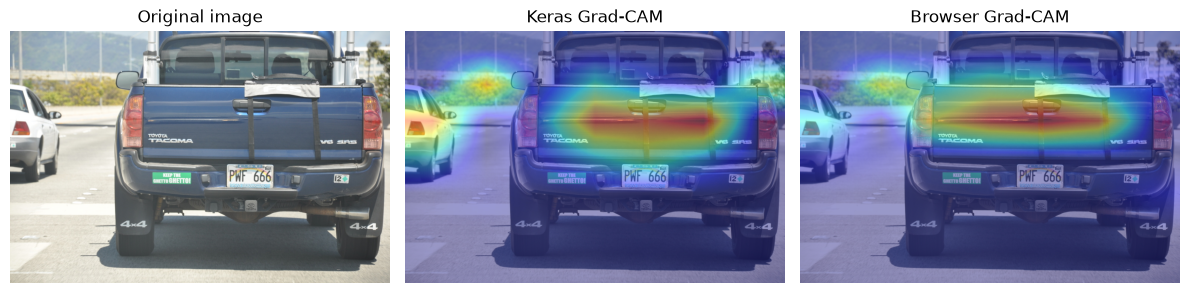

Selected configuration: Graph resize + WebGPU + standard Grad-CAM
Fallback order: WebGPU → WebGL → patched WASM → CPU
Worst Grad-CAM sample: unknown_09
Worst heatmap correlation: 0.809326
Mean heatmap correlation: 0.972978
Median browser time: 33.45 ms
Comparison saved to Model Building/Browser Test/gradcam_comparison.png


,configuration,successful_runs,failed_runs,prediction_matches,verified
0,Graph resize + WebGPU + standard Grad-CAM,60,0,60,True
1,Graph resize + WebGL + standard Grad-CAM,60,0,60,True
2,Graph resize + WASM + standard Grad-CAM,60,0,60,True
3,Graph resize + CPU + standard Grad-CAM,60,0,60,True


In [6]:
chosen_configurations = [
    "Graph resize + WebGPU + standard Grad-CAM",
    "Graph resize + WebGL + standard Grad-CAM",
    "Graph resize + WASM + standard Grad-CAM",
    "Graph resize + CPU + standard Grad-CAM",
]

verification_rows = []

for configuration in chosen_configurations:
    configuration_rows = results[
        results["configuration"].eq(configuration)
    ]

    successful_runs = int(configuration_rows["success"].sum())
    failed_runs = int((~configuration_rows["success"]).sum())
    prediction_matches = int(
        configuration_rows["prediction_match"].sum()
    )

    verification_rows.append(
        {
            "configuration": configuration,
            "successful_runs": successful_runs,
            "failed_runs": failed_runs,
            "prediction_matches": prediction_matches,
            "verified": (
                len(configuration_rows)
                == len(reference_payload["samples"])
                and successful_runs
                == len(reference_payload["samples"])
                and failed_runs == 0
                and prediction_matches
                == len(reference_payload["samples"])
            ),
        }
    )

verification_status = pd.DataFrame(verification_rows)

if not verification_status["verified"].all():
    failed_configurations = verification_status.loc[
        ~verification_status["verified"],
        "configuration",
    ].tolist()

    raise ValueError(
        "One or more chosen deployment configurations did not retain "
        "the expected benchmark result:\n"
        + "\n".join(failed_configurations)
    )

selected_configuration = (
    "Graph resize + WebGPU + standard Grad-CAM"
)

selected_results = results[
    results["configuration"].eq(selected_configuration)
    & results["success"]
].copy()

worst_result = selected_results.loc[
    selected_results["heatmap_correlation"].idxmin()
]
worst_sample_id = worst_result["sample_id"]

browser_row = next(
    (
        row
        for row in raw_payload["rows"]
        if row["configuration"] == selected_configuration
        and row["sample_id"] == worst_sample_id
        and row["success"]
    ),
    None,
)

if browser_row is None:
    raise ValueError(
        "The selected worst-case browser result was not found."
    )

reference = next(
    (
        sample
        for sample in reference_payload["samples"]
        if sample["sample_id"] == worst_sample_id
    ),
    None,
)

if reference is None:
    raise ValueError(
        "The selected worst-case Keras reference was not found."
    )

winner = {
    "configuration": selected_configuration,
    "resize_method": str(worst_result["resize_method"]),
    "backend": str(worst_result["backend"]),
    "gradcam_method": str(worst_result["gradcam_method"]),
    "successful_runs": int(selected_results["success"].sum()),
    "failed_runs": int((~selected_results["success"]).sum()),
    "prediction_matches": int(
        selected_results["prediction_match"].sum()
    ),
    "mean_max_probability_difference": float(
        selected_results[
            "maximum_probability_difference"
        ].mean()
    ),
    "lowest_heatmap_correlation": float(
        selected_results["heatmap_correlation"].min()
    ),
    "mean_heatmap_correlation": float(
        selected_results["heatmap_correlation"].mean()
    ),
    "median_total_ms": float(
        selected_results["browser_total_ms"].median()
    ),
    "p95_total_ms": float(
        selected_results["browser_total_ms"].quantile(0.95)
    ),
    "fallback_order": [
        "webgpu",
        "webgl",
        "wasm",
        "cpu",
    ],
    "selection_reason": (
        "Graph resize and standard Grad-CAM gave the strongest "
        "agreement with Keras, and WebGPU was the fastest chosen "
        "backend."
    ),
    "worst_sample_id": worst_sample_id,
}

WINNER_PATH.write_text(
    json.dumps(winner, indent=2),
    encoding="utf-8",
)

original_path = TEMP_DIR / reference["browser_path"]
original_image = Image.open(original_path).convert("RGB")

keras_heatmap = np.asarray(
    reference["heatmap"],
    dtype=np.float32,
).reshape(reference["heatmap_shape"])

browser_heatmap = np.asarray(
    browser_row["browser_heatmap"],
    dtype=np.float32,
).reshape(reference["heatmap_shape"])


def create_overlay(image, heatmap, alpha=0.4):
    resized_heatmap = Image.fromarray(
        np.uint8(np.clip(heatmap, 0, 1) * 255)
    ).resize(image.size, Image.Resampling.BILINEAR)

    heatmap_values = (
        np.asarray(resized_heatmap, dtype=np.float32) / 255.0
    )
    heatmap_rgb = plt.get_cmap("jet")(heatmap_values)[..., :3]
    image_values = np.asarray(image, dtype=np.float32) / 255.0

    return np.clip(
        (1 - alpha) * image_values + alpha * heatmap_rgb,
        0,
        1,
    )


keras_overlay = create_overlay(original_image, keras_heatmap)
browser_overlay = create_overlay(original_image, browser_heatmap)

figure, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(original_image)
axes[0].set_title("Original image")

axes[1].imshow(keras_overlay)
axes[1].set_title("Keras Grad-CAM")

axes[2].imshow(browser_overlay)
axes[2].set_title("Browser Grad-CAM")

for axis in axes:
    axis.axis("off")

figure.tight_layout()
figure.savefig(
    COMPARISON_PATH,
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close(figure)

print("Selected configuration:", selected_configuration)
print("Fallback order: WebGPU → WebGL → patched WASM → CPU")
print("Worst Grad-CAM sample:", worst_sample_id)
print(
    "Worst heatmap correlation:",
    f"{winner['lowest_heatmap_correlation']:.6f}",
)
print(
    "Mean heatmap correlation:",
    f"{winner['mean_heatmap_correlation']:.6f}",
)
print(
    "Median browser time:",
    f"{winner['median_total_ms']:.2f} ms",
)
print(
    "Comparison saved to "
    "Model Building/Browser Test/gradcam_comparison.png"
)

display(verification_status)

## 6. Final TensorFlow.js export

The verified GraphModel is saved to `Model Building/Models/Final/TensorFlowJS` and copied to `Web App/model`.

The required WASM runtime files are copied to `Web App/wasm`, the two model copies are verified with file hashes, and the temporary benchmark files are removed after successful export.

In [ ]:
def reset_folder(folder):
    if folder.exists():
        shutil.rmtree(folder)
    folder.mkdir(parents=True, exist_ok=True)


def sha256_file(path):
    digest = hashlib.sha256()

    with Path(path).open("rb") as file_handle:
        for chunk in iter(
            lambda: file_handle.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


expected_configuration = (
    "Graph resize + WebGPU + standard Grad-CAM"
)

if winner["configuration"] != expected_configuration:
    raise ValueError(
        "Code Cell 5 did not select the expected WebGPU "
        "deployment configuration."
    )

model_info = {
    "model_name": "Cat, Dog, Bird and Unknown EfficientNetV2B0",
    "keras_source": (
        "Model Building/Models/Final/"
        "cat_dog_bird_unknown.keras"
    ),
    "tensorflowjs_format": "GraphModel",
    "class_names": CLASS_NAMES,
    "input_shape": [IMAGE_SIZE, IMAGE_SIZE, 3],
    "outputs": {
        "probabilities": [None, len(CLASS_NAMES)],
        "features": list(feature_model.output_shape),
    },
    "preprocessing": {
        "colour_mode": "RGB",
        "resize": (
            "Aspect-ratio-preserving bilinear resize "
            "with padding"
        ),
        "pixel_range": "[0,255]",
        "external_rescaling": False,
        "efficientnet_preprocessing_inside_graph": True,
    },
    "decision_rule": "Highest probability",
    "gradcam": {
        "layer": last_conv_layer.name,
        "feature_shape": list(
            feature_model.output_shape[1:]
        ),
        "score": "Softmax probability",
        "weights_file": "gradcam_weights.json",
        "method": winner["gradcam_method"],
    },
    "deployment": {
        "selected_configuration": winner["configuration"],
        "resize_method": winner["resize_method"],
        "primary_backend": winner["backend"],
        "gradcam_method": winner["gradcam_method"],
        "backend_fallback_order": winner["fallback_order"],
        "selection_reason": winner["selection_reason"],
        "wasm_backend_is_patched": True,
    },
    "benchmark": {
        "seed": SEED,
        "images_per_class": SAMPLES_PER_CLASS,
        "total_images": (
            SAMPLES_PER_CLASS * len(CLASS_NAMES)
        ),
        "tested_configurations": len(
            BROWSER_CONFIGURATIONS
        ),
        "prediction_matches": int(
            winner["prediction_matches"]
        ),
        "successful_runs": int(
            winner["successful_runs"]
        ),
        "failed_runs": int(winner["failed_runs"]),
        "mean_max_probability_difference": float(
            winner[
                "mean_max_probability_difference"
            ]
        ),
        "lowest_heatmap_correlation": float(
            winner["lowest_heatmap_correlation"]
        ),
        "mean_heatmap_correlation": float(
            winner["mean_heatmap_correlation"]
        ),
        "median_total_ms": float(
            winner["median_total_ms"]
        ),
        "p95_total_ms": float(
            winner["p95_total_ms"]
        ),
        "worst_gradcam_sample": winner[
            "worst_sample_id"
        ],
        "results": (
            "Model Building/Browser Test/results.csv"
        ),
        "comparison": (
            "Model Building/Browser Test/"
            "gradcam_comparison.png"
        ),
    },
    "tensorflow_version": tf.__version__,
    "tensorflowjs_version": raw_payload.get(
        "tfjs_version",
        TFJS_VERSION,
    ),
    "model_file": "model.json",
}

class_names_payload = {
    "class_names": CLASS_NAMES,
    "class_order": {
        class_name: class_index
        for class_index, class_name
        in enumerate(CLASS_NAMES)
    },
}

temporary_model_dir = (
    TEMP_TFJS_MODELS_DIR / "classifier"
)
temporary_model_available = (
    (temporary_model_dir / "model.json").is_file()
    and (TEMP_DIR / "gradcam_weights.json").is_file()
)

if temporary_model_available:
    reset_folder(FINAL_TFJS_DIR)

    for source_file in temporary_model_dir.iterdir():
        if source_file.is_file():
            shutil.copy2(
                source_file,
                FINAL_TFJS_DIR / source_file.name,
            )

    shutil.copy2(
        TEMP_DIR / "gradcam_weights.json",
        FINAL_TFJS_DIR / "gradcam_weights.json",
    )

existing_final_model_files = [
    FINAL_TFJS_DIR / "model.json",
    FINAL_TFJS_DIR / "gradcam_weights.json",
]

if not all(
    path.is_file()
    for path in existing_final_model_files
):
    raise FileNotFoundError(
        "The temporary GraphModel is unavailable and the "
        "previous final GraphModel copy is incomplete."
    )

(FINAL_TFJS_DIR / "class_names.json").write_text(
    json.dumps(class_names_payload, indent=2),
    encoding="utf-8",
)
(FINAL_TFJS_DIR / "model_info.json").write_text(
    json.dumps(model_info, indent=2),
    encoding="utf-8",
)

reset_folder(WEB_APP_MODEL_DIR)

for source_file in FINAL_TFJS_DIR.rglob("*"):
    if not source_file.is_file():
        continue

    relative_path = source_file.relative_to(
        FINAL_TFJS_DIR
    )
    destination_file = (
        WEB_APP_MODEL_DIR / relative_path
    )
    destination_file.parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    shutil.copy2(
        source_file,
        destination_file,
    )

wasm_source_dir = (
    TEMP_VENDOR_DIR
    / "tfjs-backend-wasm"
    / "package"
    / "dist"
)
patched_wasm_source = (
    wasm_source_dir / "tf-backend-wasm.js"
)
patch_marker = (
    "Notebook 5 WASM rank-4 bias compatibility patch"
)
temporary_wasm_files = sorted(
    wasm_source_dir.glob("*.wasm")
)

temporary_wasm_available = (
    patched_wasm_source.is_file()
    and bool(temporary_wasm_files)
    and patch_marker
    in patched_wasm_source.read_text(
        encoding="utf-8"
    )
)

if temporary_wasm_available:
    reset_folder(WEB_APP_WASM_DIR)

    shutil.copy2(
        patched_wasm_source,
        WEB_APP_WASM_DIR
        / patched_wasm_source.name,
    )

    for wasm_file in temporary_wasm_files:
        shutil.copy2(
            wasm_file,
            WEB_APP_WASM_DIR / wasm_file.name,
        )

deployed_wasm_js = (
    WEB_APP_WASM_DIR / "tf-backend-wasm.js"
)
deployed_wasm_files = sorted(
    WEB_APP_WASM_DIR.glob("*.wasm")
)

if not deployed_wasm_js.is_file():
    raise FileNotFoundError(
        "The patched TensorFlow.js WASM backend "
        "was not found."
    )

if patch_marker not in deployed_wasm_js.read_text(
    encoding="utf-8"
):
    raise ValueError(
        "The deployed TensorFlow.js WASM backend "
        "does not contain the compatibility patch."
    )

if not deployed_wasm_files:
    raise FileNotFoundError(
        "No deployed TensorFlow.js WASM binaries "
        "were found."
    )

required_files = [
    FINAL_TFJS_DIR / "model.json",
    FINAL_TFJS_DIR / "gradcam_weights.json",
    FINAL_TFJS_DIR / "class_names.json",
    FINAL_TFJS_DIR / "model_info.json",
    WEB_APP_MODEL_DIR / "model.json",
    WEB_APP_MODEL_DIR / "gradcam_weights.json",
    WEB_APP_MODEL_DIR / "class_names.json",
    WEB_APP_MODEL_DIR / "model_info.json",
    WEB_APP_WASM_DIR / "tf-backend-wasm.js",
    RESULTS_PATH,
    COMPARISON_PATH,
]

missing_files = [
    path
    for path in required_files
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "Missing final files:\n"
        + "\n".join(
            project_relative(path)
            for path in missing_files
        )
    )

model_building_files = {
    path.relative_to(
        FINAL_TFJS_DIR
    ).as_posix(): sha256_file(path)
    for path in FINAL_TFJS_DIR.rglob("*")
    if path.is_file()
}

web_app_files = {
    path.relative_to(
        WEB_APP_MODEL_DIR
    ).as_posix(): sha256_file(path)
    for path in WEB_APP_MODEL_DIR.rglob("*")
    if path.is_file()
}

if model_building_files != web_app_files:
    raise ValueError(
        "The Model Building and Web App "
        "TensorFlow.js copies are not identical."
    )

model_size_bytes = sum(
    path.stat().st_size
    for path in FINAL_TFJS_DIR.rglob("*")
    if path.is_file()
)


def stop_headless_browser_processes():
    if (
        "browser_process" in globals()
        and browser_process.poll() is None
    ):
        browser_process.terminate()

        try:
            browser_process.wait(timeout=10)
        except subprocess.TimeoutExpired:
            browser_process.kill()

            try:
                browser_process.wait(timeout=10)
            except subprocess.TimeoutExpired:
                pass

    profile_targets = []

    if "profile_argument" in globals():
        profile_targets.append(
            str(profile_argument)
        )

    if "profile_dir" in globals():
        profile_targets.append(
            Path(profile_dir).name
        )

    profile_targets = [
        target
        for target in profile_targets
        if target
    ]

    if not profile_targets:
        return

    powershell_path = Path(
        "/mnt/c/Windows/System32/"
        "WindowsPowerShell/v1.0/"
        "powershell.exe"
    )

    if not powershell_path.is_file():
        return

    target_conditions = " -or ".join(
        (
            "$_.CommandLine.Contains("
            f"'{target.replace(chr(39), chr(39) * 2)}'"
            ")"
        )
        for target in profile_targets
    )

    powershell_script = f"""
Get-CimInstance Win32_Process |
Where-Object {{
    $_.ProcessId -ne $PID -and
    $_.CommandLine -and
    ({target_conditions})
}} |
ForEach-Object {{
    Stop-Process `
        -Id $_.ProcessId `
        -Force `
        -ErrorAction SilentlyContinue
}}
"""

    subprocess.run(
        [
            str(powershell_path),
            "-NoProfile",
            "-Command",
            powershell_script,
        ],
        capture_output=True,
        text=True,
        timeout=30,
        check=False,
    )


stop_headless_browser_processes()

cleanup_error = None

for attempt in range(20):
    try:
        if TEMP_DIR.exists():
            shutil.rmtree(TEMP_DIR)

        cleanup_error = None
        break

    except PermissionError as error:
        cleanup_error = error
        stop_headless_browser_processes()
        time.sleep(0.75)

if cleanup_error is not None:
    raise PermissionError(
        "The final export was verified, but the temporary "
        "browser folder is still locked by a browser process. "
        "Close any remaining headless Edge or Chrome process "
        "and run Code Cell 6 again."
    ) from cleanup_error

print("Final TensorFlow.js GraphModel export completed.")
print(
    "Selected configuration:",
    winner["configuration"],
)
print(
    "Fallback order: "
    "WebGPU → WebGL → patched WASM → CPU"
)
print(
    "Authoritative copy: "
    "Model Building/Models/Final/TensorFlowJS"
)
print("Deployment copy: Web App/model")
print("Patched WASM runtime: Web App/wasm")
print(
    "Benchmark results: "
    "Model Building/Browser Test/results.csv"
)
print(
    "Grad-CAM comparison: "
    "Model Building/Browser Test/"
    "gradcam_comparison.png"
)
print(
    "TensorFlow.js model size:",
    f"{model_size_bytes / (1024 ** 2):.2f} MB",
)
print(
    "Verified identical model files:",
    len(model_building_files),
)
print(
    "WASM runtime files copied:",
    len(deployed_wasm_files) + 1,
)
print("Temporary browser-test files removed.")